# Recipe Traffic Prediction Report

## Data Validation

The dataset underwent a comprehensive validation process to ensure its integrity and readiness for analysis. Below is a detailed account of the steps taken to clean and prepare the data:


#### 1. Nutrient Columns (`calories`, `carbohydrate`, `sugar`, `protein`)

Missing Values
- **Issue**: 52 missing values (~5.5% of the dataset), all occurring in the same rows.  
- **Action Taken**: Imputed missing values using the **median** grouped by `category` and `servings`, preserving the contextual relationship between nutrients and recipe categories.  

Distribution 
- Nutrient columns exhibited heavily skewed distributions, reflecting variability across categories.  
- **Action Taken**: Applied **Box-Cox transformation** during feature engineering to improve normality, ensuring better suitability for statistical tests and modeling.  

Outliers  
- **Observation**: Outliers aligned with domain knowledge (e.g., high protein in **Chicken** and **Meat**, high sugar in **Desserts**).  
- **Action Taken**: Retained all outliers as they offered meaningful insights for traffic prediction.  
- **Limitation**: The absence of `fat` data, a significant calorie contributor, limited deeper analysis of calorie-related outliers.  


#### 2. Category Column

Cleaning  
- Contained 11 unique values, including an unexpected entry, `Chicken Breast`.  
- **Action Taken**: Merged `Chicken Breast` with `Chicken` to ensure consistency.  

Type Conversion  
- Converted the column from `object` to `category` dtype to optimize storage and processing efficiency.  


#### 3. Servings Column

Cleaning  
- Included six unique values, with some labeled as `"as a snack"`.  
- **Action Taken**: Removed the `"as a snack"` text and converted entries into numeric values.  

Type Conversion  
- Changed from `object` to `int` dtype to reflect its numerical nature.  


#### 4. High Traffic Column

Missing Values  
- **Issue**: 373 missing values (~39.3% of the dataset).  
- **Action Taken**: Replaced all `nan` values with `"Low"` to signify low traffic.  

Type Conversion  
- Converted from `object` to `category` dtype for efficient storage and processing.  


### Observations and Key Decisions

**Outliers**  
- Retained across all columns due to alignment with domain knowledge and their potential value for predictive modeling.  

**Skewness**  
- Nutrient columns displayed significant skewness, addressed using **Box-Cox transformations** for improved normality.  

**Interaction Terms**  
- Potential interactions between `servings` and nutrients were flagged for feature engineering to uncover additional insights.  


The data validation process ensured the dataset was clean, consistent, and ready for downstream exploratory analysis and predictive modeling.

---

## Exploratory Data Analysis (EDA)

### Data Preparation

**Distributions and Transformations**  
- Nutrient columns showed heavy skewness due to variability across categories.  
- **Action Taken**: Applied **Box-Cox transformations** to both raw nutrient columns and derived `nutrient_by_serving` features (e.g., `protein_by_serving`, `sugar_by_serving`).  
- Post-transformation normality improved significantly, as confirmed by Shapiro-Wilk tests.  


### Key Findings

**Category vs. Traffic (Chi-Square Test)**  
- **Result**: Significant association between `category` and traffic levels.  
  - **Chi-Square Statistic**: 318.294  
  - **p-value**: 0.00000  
- **Insight**:  
  - High traffic: **Pork**, **Potato**, and **Vegetable**.  
  - Low traffic: **Beverages** and **Breakfast**.  

**Servings vs. Traffic (Chi-Square Test)**  
- **Result**: No significant association.  
  - **Chi-Square Statistic**: 2.737  
  - **p-value**: 0.43398  
- Interaction terms between `servings` and nutrients were flagged for further exploration in the modeling phase.  


**T-Tests**  
- Significant nutrient differences between high-traffic and low-traffic recipes:  
  - **Calories**: p = 0.03445  
  - **Protein**: p = 0.00006  
  - **Sugar**: p = 0.04631  
- Derived features like `protein_by_serving` (p = 0.00036) and `sugar_by_serving` (p = 0.02041) also showed statistical significance.  


**Correlation Insights**  

Original Nutrient Data:  
- Weak but statistically significant correlations with traffic:  
  - **Calories**: r = 0.069  
  - **Carbohydrates**: r = 0.072  
  - **Sugar**: r = -0.079  
- Categories with strongest correlations:  
  - Positive: **Pork (0.200)**, **Potato (0.220)**, **Vegetable (0.240)**  
  - Negative: **Beverages (-0.370)**, **Breakfast (-0.214)**  

Nutrients by Serving:  
- **Sugar by Serving**: r = -0.065 (weak negative correlation).  
- Other derived features showed no strong correlations.  


### Actions Taken

1. **Feature Engineering**:  
   - Derived `nutrient_by_serving` features (e.g., `protein_by_serving`) to explore hidden interactions with traffic.  
 
2. **Hypothesis Formation**:  
   - Nutrients such as **calories**, **protein**, and their derived features are expected to contribute meaningfully to traffic predictions.
   - Categories such as  **Pork**, **Potato**, and **Vegetable** are identified as strong predictors of high traffic


The EDA phase identified critical patterns and predictors for high traffic recipes, which guided feature selection and model development.

---

## Model Development

**Problem Type**  

A binary classification problem aimed at predicting whether a recipe would experience high traffic (`1`) or low traffic (`0`).  

**Baseline Model**  

The **Logistic Regression** model was chosen as the baseline due to its simplicity, ease of implementation, and interpretability. It also provides intuitive insights into feature importance and serves as a benchmark for evaluating the performance of more advanced models. 

**Comparison Models**  

To improve upon the baseline, several advanced models were developed and evaluated:
1. **Random Forest**: Explored both default and tuned versions.  
2. **SVM**: Evaluated with linear and non-linear kernels.  
3. **Gradient Boosting**: Assessed default and tuned variants for performance gains.  

All models were evaluated using cross-validation to ensure generalizability and robustness. The models were optimized to achieve the business goal of accurately predicting high-traffic recipes while minimizing the risk of displaying low-traffic recipes as high-traffic.

---

## Model Evaluation

**Metrics**  
The following metrics were employed to evaluate model performance, aligned with the business objectives:

1. **Precision (Primary Metric)**:  
   - Precision was selected as the primary metric to **minimize false positives**.  
   - Target: Precision **≥ 80%**.  

2. **F1-Score (Secondary Metric)**:  
   - The F1-Score ensures a balance between precision and recall, preventing overemphasis on one at the expense of the other.
   - Particularly useful for datasets with mild imbalances.  

3. **AUC-ROC**:  
   - Measures the ability of the model to rank predictions effectively across thresholds, providing a comprehensive view of model performance.  


**Performance Summary**

The table below summarizes the performance of all models, comparing their F1-Score, AUC, precision, and recall across the **Original Dataset** and the **Nutrients by Serving Dataset**:

#### Original Dataset

| **Model**                  | **F1-Score** | **AUC**   | **Precision** | **Recall** |
|----------------------------|--------------|-----------|---------------|------------|
| Logistic Regression        | 0.809        | 0.870     | 0.87          | 0.76       |
| Gradient Boosting (Tuned)  | 0.787        | 0.851     | 0.82          | 0.76       |

#### Nutrients by Serving Dataset

| **Model**                  | **F1-Score** | **AUC**   | **Precision** | **Recall** |
|----------------------------|--------------|-----------|---------------|------------|
| Logistic Regression        | 0.794        | 0.867     | 0.86          | 0.74       |
| Gradient Boosting (Tuned)  | 0.828        | 0.837     | 0.74          | 0.94       |


**Insights**  

**Logistic Regression**:  
- Highest precision (**87%**), aligning with the business goal of minimizing false positives.  
- Highly interpretable, offering insights into category importance.  

**Gradient Boosting (Tuned)**:  
- Highest F1-Score (**0.828**) and robust recall (**94%**).  
- Lower precision (74%), leading to slightly more false positives.  


**Feature Importance**

The top features influencing **Logistic Regression (Original Dataset)** predictions were:
- category_Vegetable (importance: 2.32)
- category_Potato (importance: 1.72)
- category_Pork (importance: 1.30)

These results align with findings from the exploratory analysis, where these categories were strongly associated with high traffic.

The most important features for **Gradient Boosting (Nutrients by Serving Dataset)** were:
- category_Beverages (importance: 0.42)
- category_Chicken (importance: 0.27)
- category_Breakfast (importance: 0.20)

Interestingly, categories such as **Beverages** and **Breakfast**, which Logistic Regression linked to low traffic, appeared as important features in Gradient Boosting, explaining its higher recall at the expense of precision.

---

## Final Recommendations

**Model Recommendation**
1. Primary Model of Choice: Logistic Regression
   - Provides the highest **precision** (87%), minimizing false positives and ensuring accurate identification of high-traffic recipes.
   - Offers intuitive insights into feature importance, supporting strategic business decisions.

2. Alternative Model: Gradient Boosting (Tuned)
   - Achieves the highest **F1-Score** (0.83) and robust **recall** (94%), making it ideal for scenarios where identifying more high-traffic recipes outweighs the risk of false positives.


**Business Recommendations**

1. Optimize Recipe Categories:
   - Focus on promoting high-traffic categories such as **Vegetable**, **Potato**, and **Pork**.
   - Avoid overemphasizing low-traffic categories, including **Beverages**, **Breakfast**, and **Chicken**.

2. Data Enrichment:
   - Include `fat` as a feature, as its absence limited the interpretability of calorie-related insights.
   - Gather additional data on user preferences and regional trends for more tailored predictions.

---

## Conclusion
Logistic Regression emerges as the best-fit model for this business case, ensuring high confidence in identifying high-traffic recipes with minimal false positives. Gradient Boosting offers a strong alternative for recall-focused objectives, making it suitable for scenarios requiring a broader capture of high-traffic recipes. By implementing the recommendations above, the business can optimize recipe selection and traffic generation while maintaining user satisfaction.

---

# Data Validation

In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file = 'recipe_site_traffic_2212.csv'
data = pd.read_csv(file)

print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB
None


,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [4]:
def check_unique_values(data):
    for column in data.columns:
        if pd.api.types.is_numeric_dtype(data[column]):
            print(f"Column: {column} - Unique Values Count: {data[column].nunique()}")
        else:
            print(f"Column: {column} - Unique Values: {data[column].unique()}")

check_unique_values(data)

Column: recipe - Unique Values Count: 947
Column: calories - Unique Values Count: 891
Column: carbohydrate - Unique Values Count: 835
Column: sugar - Unique Values Count: 666
Column: protein - Unique Values Count: 772
Column: category - Unique Values: ['Pork' 'Potato' 'Breakfast' 'Beverages' 'One Dish Meal' 'Chicken Breast'
 'Lunch/Snacks' 'Chicken' 'Vegetable' 'Meat' 'Dessert']
Column: servings - Unique Values: ['6' '4' '1' '2' '4 as a snack' '6 as a snack']
Column: high_traffic - Unique Values: ['High' nan]


In [5]:
missing_values = data.isna().sum()
missing_proportion = missing_values / len(data)

print(missing_values)
print(missing_proportion)

recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64
recipe          0.000000
calories        0.054910
carbohydrate    0.054910
sugar           0.054910
protein         0.054910
category        0.000000
servings        0.000000
high_traffic    0.393875
dtype: float64


In [6]:
nutrients_column = ['calories', 'protein', 'carbohydrate', 'sugar']

print(len(data[data[nutrients_column].isna().any(axis=1)]))
data[data[nutrients_column].isna().any(axis=1)]

52


,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
23,24,NaN,NaN,NaN,NaN,Meat,2,NaN
48,49,NaN,NaN,NaN,NaN,Chicken Breast,4,NaN
82,83,NaN,NaN,NaN,NaN,Meat,4,High
89,90,NaN,NaN,NaN,NaN,Pork,6,High
116,117,NaN,NaN,NaN,NaN,Chicken Breast,6,High
121,122,NaN,NaN,NaN,NaN,Dessert,2,High
136,137,NaN,NaN,NaN,NaN,One Dish Meal,2,High
149,150,NaN,NaN,NaN,NaN,Potato,2,High
187,188,NaN,NaN,NaN,NaN,Pork,4,High


#### Data Validation - Initial Observations

1. **Missing Values**
   - `calories`, `carbohydrate`, `sugar`, and `protein` have 52 missing values, accounting for approximately 5.5% of the dataset.
     - All 52 missing values occur in the same rows.
     - Further analysis is required to determine the appropriate imputation method.
   - The `high_traffic` column contains 373 missing values, representing 39.3% of the dataset.
     - These missing values consist of `['High', nan]`.
     - Plan to replace `nan` values with `Low` to indicate low traffic data.

2. **Data Types and Representations**
   - `calories`, `carbohydrate`, `sugar`, and `protein` are of `float` dtype.
     - This is an appropriate representation for nutritional values.
   - `category` and `high_traffic` are of `object` dtype.
     - These are suitable for categorical data.
     - Plan to convert them to `category` dtype for optimized processing.
   - The `servings` column is of `object` dtype but contains numerical values.
     - A numerical representation (`int`) is more appropriate for this column.
     - Plan to convert to `int` dtype.

Verifying expected categories in `category` column against provided groupings: ` (Lunch/Snacks', 'Beverages', 'Potato', 'Vegetable', 'Meat', 'Chicken, 'Pork', 'Dessert', 'Breakfast', 'One Dish Meal')`

In [7]:
expected_categories = [
    'Lunch/Snacks', 'Beverages', 'Potato', 'Vegetable', 
    'Meat', 'Chicken', 'Pork', 'Dessert', 'Breakfast', 'One Dish Meal'
]

unexpected_categories = set(data['category'].unique()) - set(expected_categories)
print(f"Unexpected Categories: {unexpected_categories}")

Unexpected Categories: {'Chicken Breast'}


#### Cleaning Data

- `category` column contained 11 unique values, with an unexpected `Chicken Breast` value. To merge it with `Chicken` column.
- `servings` column has 6 unique values with 2 containing "as a snack". To remove the string `as a snack`.

In [8]:
data['category'] = data['category'].replace('Chicken Breast', 'Chicken')
data['servings'] = data['servings'].str.replace('as a snack', '')
data['high_traffic'] = data['high_traffic'].fillna('Low')
data.rename(columns={'high_traffic': 'traffic'}, inplace=True)
data.set_index('recipe', inplace=True)

data = data.astype({
    'category': 'category',
    'traffic': 'category',
    'servings': 'int'
})

print(data.info())
check_unique_values(data)

<class 'pandas.core.frame.DataFrame'>
Index: 947 entries, 1 to 947
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   calories      895 non-null    float64 
 1   carbohydrate  895 non-null    float64 
 2   sugar         895 non-null    float64 
 3   protein       895 non-null    float64 
 4   category      947 non-null    category
 5   servings      947 non-null    int32   
 6   traffic       947 non-null    category
dtypes: category(2), float64(4), int32(1)
memory usage: 43.0 KB
None
Column: calories - Unique Values Count: 891
Column: carbohydrate - Unique Values Count: 835
Column: sugar - Unique Values Count: 666
Column: protein - Unique Values Count: 772
Column: category - Unique Values: ['Pork', 'Potato', 'Breakfast', 'Beverages', 'One Dish Meal', 'Chicken', 'Lunch/Snacks', 'Vegetable', 'Meat', 'Dessert']
Categories (10, object): ['Beverages', 'Breakfast', 'Chicken', 'Dessert', ..., 'One Dish Meal', 'Pork', '

#### Handling Missing Values and Outliers

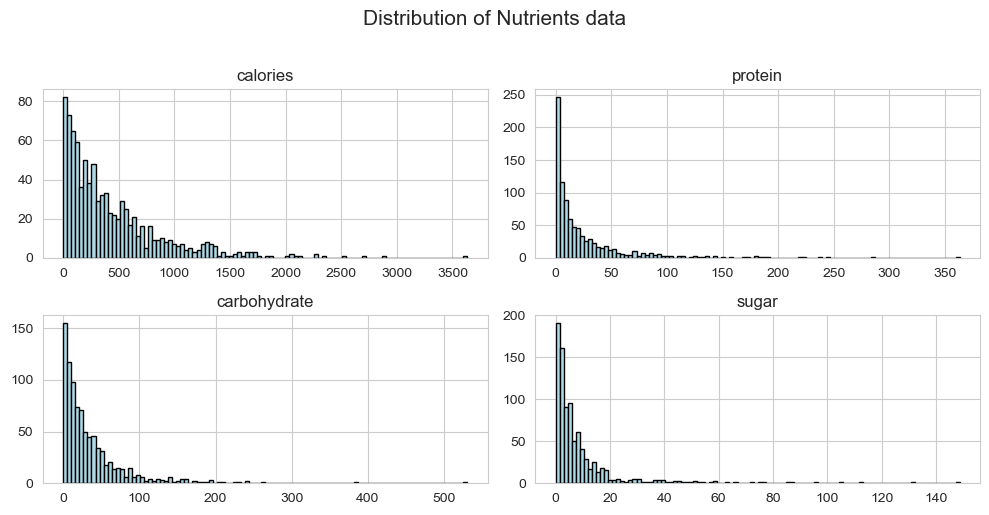

In [9]:
sns.set_style('whitegrid')

data[nutrients_column].hist(figsize=(10, 5), bins=100, color='lightblue', edgecolor='black')
plt.suptitle("Distribution of Nutrients data", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

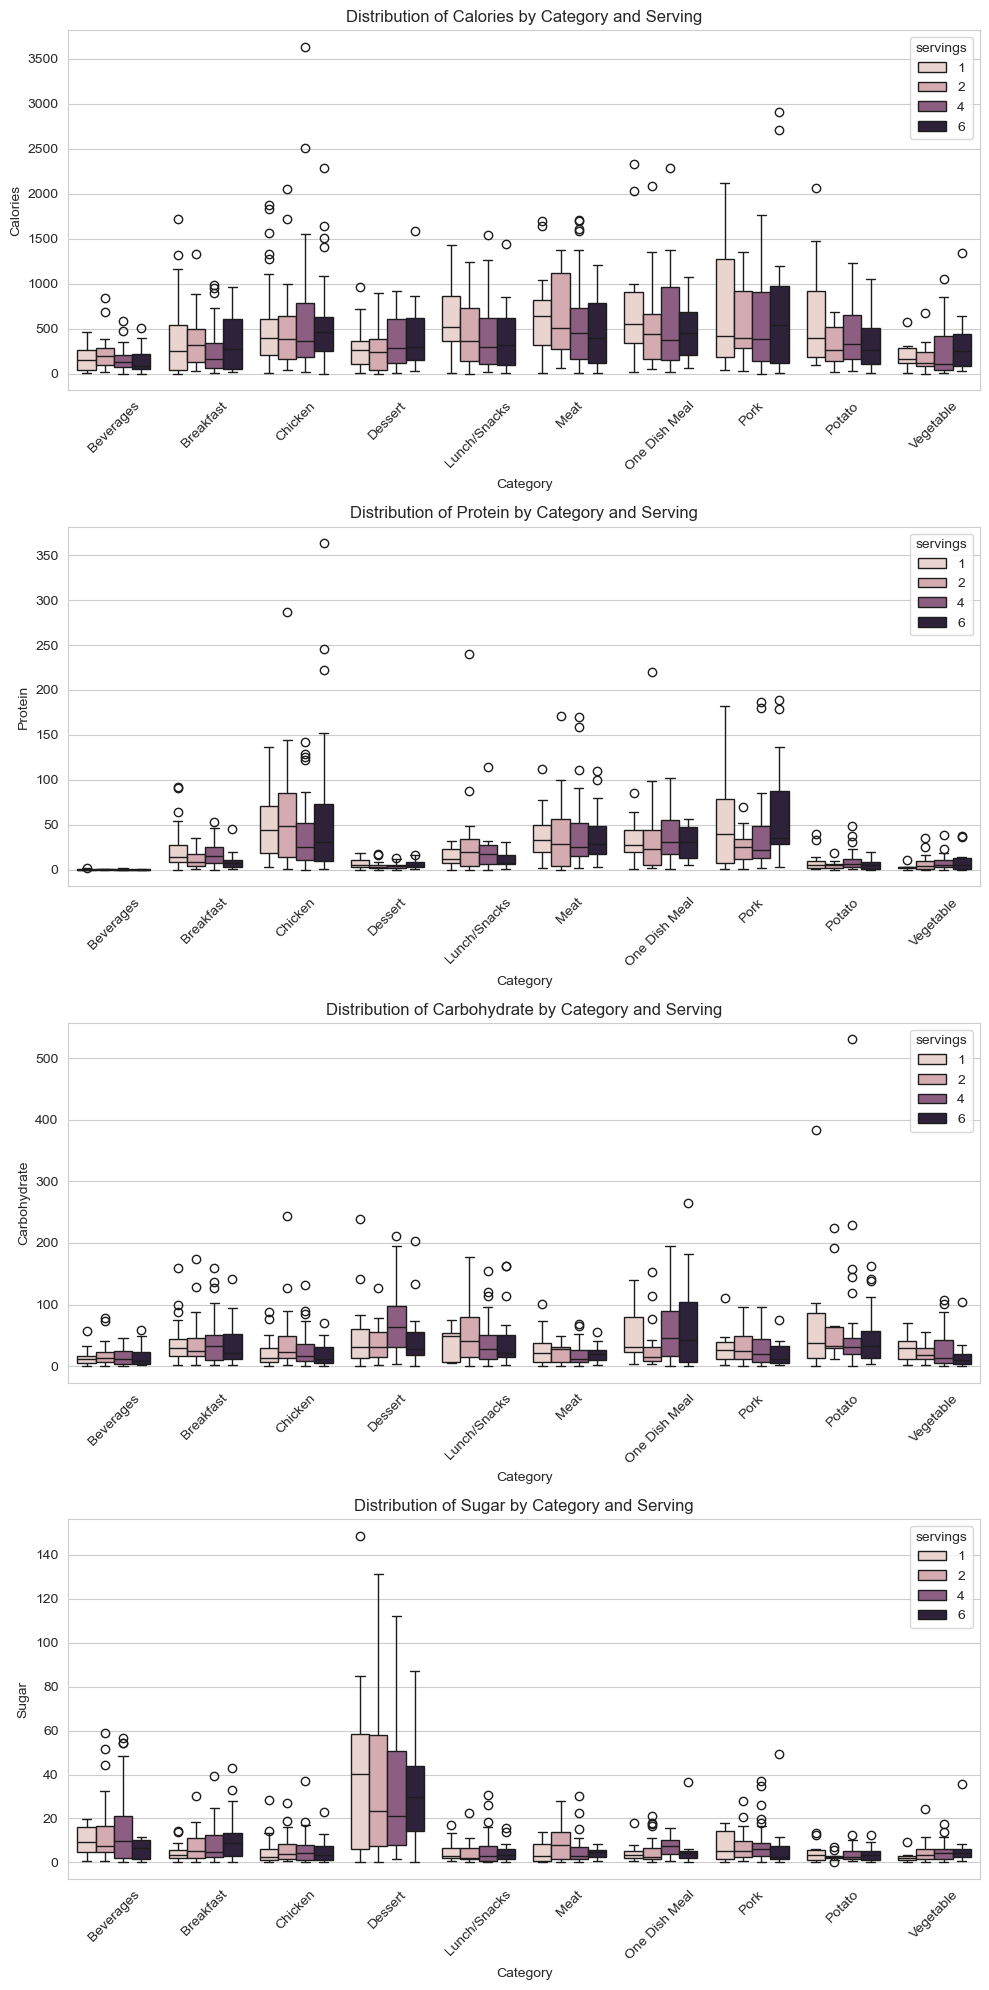

In [10]:
fig, axes = plt.subplots(len(nutrients_column), 1, figsize=(10, 20), sharex=False)

for i, nutrient in enumerate(nutrients_column):
    
    sns.boxplot(data=data, x='category', y=nutrient, hue='servings', ax=axes[i])
    axes[i].set_title(f'Distribution of {nutrient.capitalize()} by Category and Serving')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel(nutrient.capitalize())
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
def identify_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data < lower_bound) | (data > upper_bound)]

outliers = {col: identify_outliers(data[col]) for col in data[nutrients_column]}
outlier_categories = {
    feature: data.loc[outliers[feature].index, "category"].value_counts()
    for feature in ["calories", "carbohydrate", "sugar", "protein"]
}

unique_outlier_indices = set().union(*[outliers[feature].index for feature in ["calories", "carbohydrate", "sugar", "protein"]])
total_unique_outliers = len(unique_outlier_indices)

print(outlier_categories)
print(f"Total unique outliers: {total_unique_outliers}")
print(f"Outlier proportion: {total_unique_outliers / len(data):.2f}")

{'calories': category
Chicken          16
Meat              9
Pork              7
One Dish Meal     6
Lunch/Snacks      3
Breakfast         2
Potato            2
Dessert           1
Vegetable         1
Beverages         0
Name: count, dtype: int64, 'carbohydrate': category
Potato           13
Dessert          12
One Dish Meal    10
Breakfast         8
Lunch/Snacks      7
Chicken           3
Vegetable         3
Meat              1
Pork              1
Beverages         0
Name: count, dtype: int64, 'sugar': category
Dessert          41
Beverages        13
Breakfast         6
Pork              5
Chicken           4
Meat              4
Lunch/Snacks      3
Vegetable         2
One Dish Meal     1
Potato            0
Name: count, dtype: int64, 'protein': category
Chicken          39
Pork             14
Meat             12
One Dish Meal     7
Lunch/Snacks      3
Breakfast         2
Beverages         0
Dessert           0
Potato            0
Vegetable         0
Name: count, dtype: int64}
Total u

#### Further Observations

1. **Distribution**
   - All nutrient columns (`calories`, `carbohydrate`, `sugar`, and `protein`) exhibit heavily skewed distributions.
     - This skewness will need to be considered for downstream analysis, especially for statistical tests that assume normality. Transformations may be necessary.

2. **Outliers**
   - Extreme outliers are consistently aligned with domain knowledge and are observed in the following:
     - `protein`: Most outliers come from `Chicken`, `Meat`, and `Pork` categories, which intuitively are protein-heavy.
     - `sugar`: Most outliers originate from the `Dessert` category, which aligns with the high sugar content typically found in desserts.
     - `carbohydrate`: Outliers are primarily from `Dessert` and `Potatoes` categories. This is consistent with potatoes being carb-heavy and desserts often having high carbohydrate content due to sugar.

   - The `calories` column shows outliers across multiple categories. However, a significant missing component is `fat`, which contributes substantially to calorie count. The absence of this data complicates the analysis of true calorie content. As such, it is challenging to determine whether the observed outliers are due to missing fat content or data errors.

   - **Decision**: Outliers will not be removed or capped, as they align with domain knowledge and may hold valuable insights that could contribute meaningfully to the analysis.

#### Plan for Handling Missing Values

- The nutrient columns (`calories`, `carbohydrate`, `sugar`, and `protein`) exhibit skewed distributions due to varying nutrient content across food categories.
  - **Imputation Method**: Missing values will be imputed by grouping data by `category` and `servings` to account for these variations.
  - **Imputation Strategy**: The median will be used for imputation as it is robust to skewness and outliers, making it more reliable than the mean.

In [12]:
for col in nutrients_column:
    data[col] = data[col].fillna(data.groupby(['category', 'servings'])[col].transform('median'))

data.isna().sum()

C:\Users\EK\AppData\Local\Temp\ipykernel_6852\686157053.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data[col] = data[col].fillna(data.groupby(['category', 'servings'])[col].transform('median'))


calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
traffic         0
dtype: int64

# Exploratory Data Analysis


In [13]:
from scipy.stats import chi2_contingency, shapiro, ttest_ind, boxcox, pointbiserialr

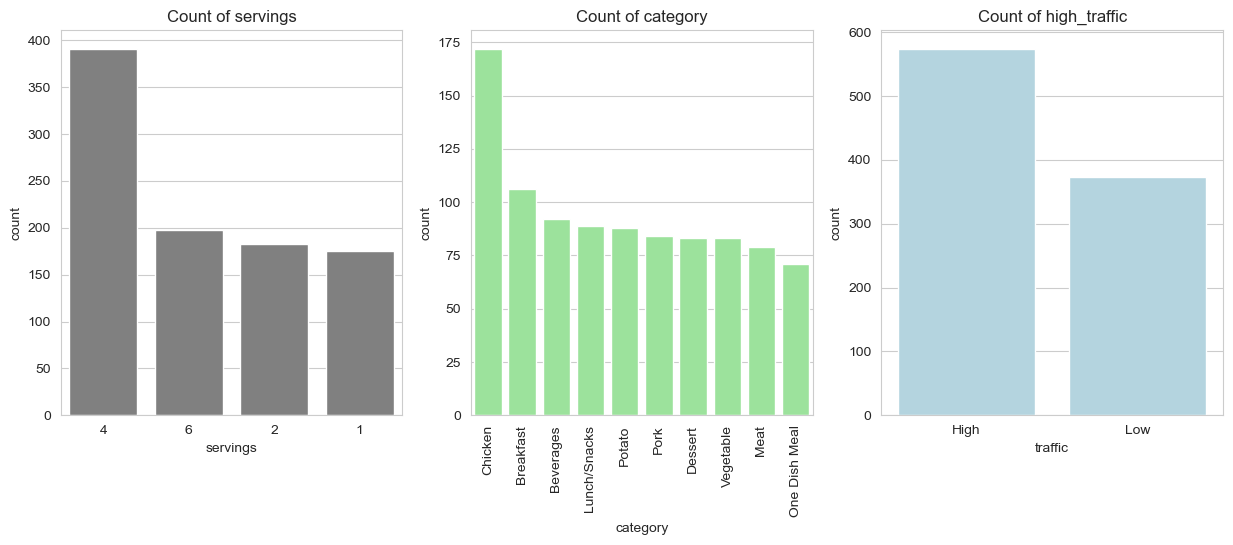

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.countplot(x=data['servings'], color='gray', ax=axes[0], order=data['servings'].value_counts().index)
axes[0].set_title('Count of servings')

sns.countplot(x=data['category'], color='lightgreen', order=data['category'].value_counts().index, ax=axes[1])
axes[1].set_title('Count of category')

sns.countplot(x=data['traffic'], color='lightblue', ax=axes[2]).set(title='Count of high_traffic')

axes[1].tick_params(axis='x', rotation=90)

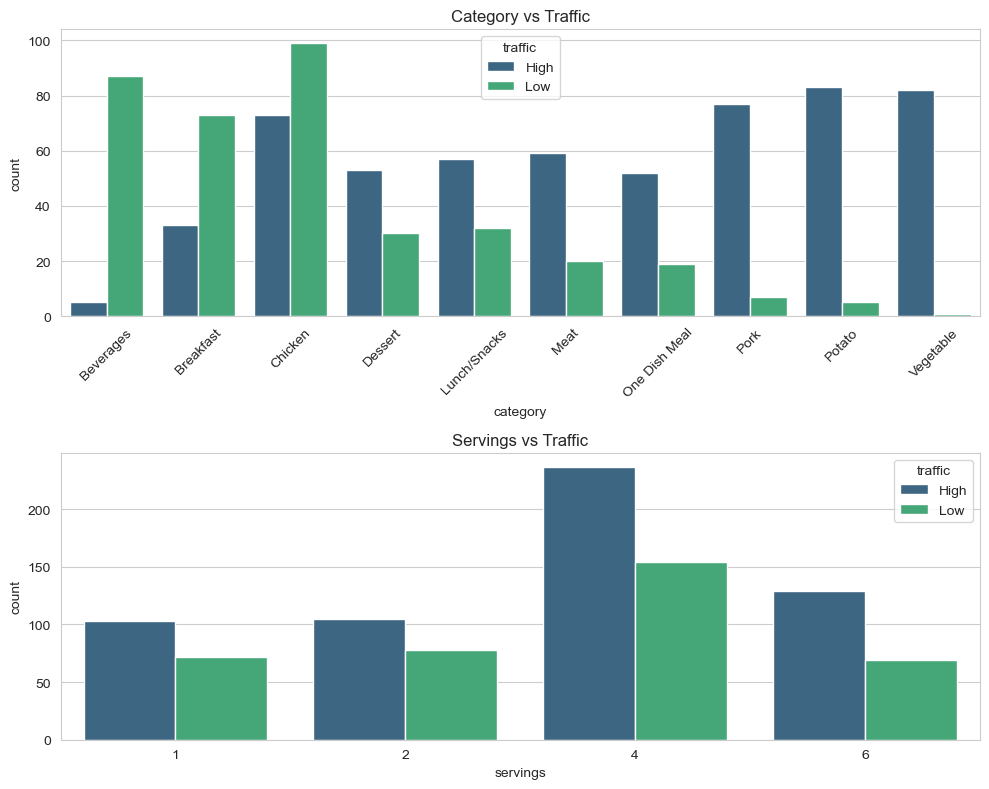

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10,8))

sns.countplot(x='category', hue='traffic', data=data, palette='viridis', ax=axes[0])
axes[0].set_title('Category vs Traffic')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='servings', hue='traffic', data=data, palette='viridis', ax=axes[1])
axes[1].set_title('Servings vs Traffic')

plt.tight_layout()
plt.show()

In [16]:
category_table = pd.crosstab(data['category'], data['traffic'])
servings_table = pd.crosstab(data['servings'], data['traffic'])

chi2, p, dof, expected = chi2_contingency(category_table)
print(f"Category vs Traffic: chi2 = {chi2:.3f}, p-value = {p:.5f}, dof = {dof}")

chi2, p, dof, expected = chi2_contingency(servings_table)
print(f"Servings vs Traffic: chi2 = {chi2:.3f}, p-value = {p:.5f}, dof = {dof}")

Category vs Traffic: chi2 = 318.294, p-value = 0.00000, dof = 9
Servings vs Traffic: chi2 = 2.737, p-value = 0.43398, dof = 3


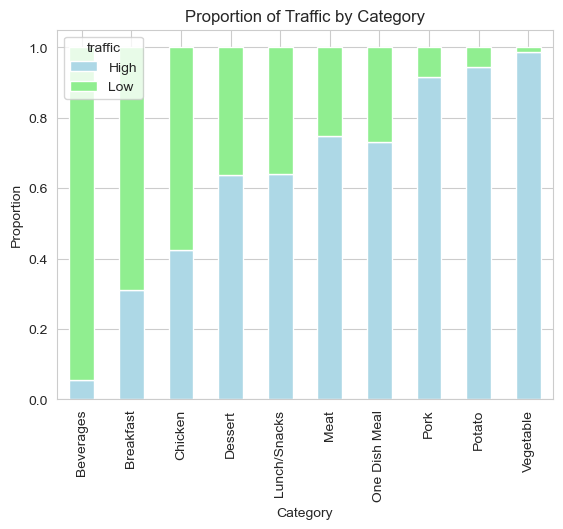

traffic            High       Low
category                         
Beverages      0.054348  0.945652
Breakfast      0.311321  0.688679
Chicken        0.424419  0.575581
Dessert        0.638554  0.361446
Lunch/Snacks   0.640449  0.359551
Meat           0.746835  0.253165
One Dish Meal  0.732394  0.267606
Pork           0.916667  0.083333
Potato         0.943182  0.056818
Vegetable      0.987952  0.012048


In [17]:
category_traffic = category_table.div(category_table.sum(axis=1), axis=0)
category_traffic.plot(kind='bar', stacked=True, color=['lightblue', 'lightgreen'])

plt.title('Proportion of Traffic by Category')
plt.ylabel('Proportion')
plt.xlabel('Category')
plt.show()

print(category_traffic)

In [18]:
for category in category_table.index:
    observed_counts = category_table.loc[category].values
    expected_counts = [sum(observed_counts) / 2] * 2

    chi2, p, dof, expected = chi2_contingency([observed_counts, expected_counts])

    print(f"Category: {category}")
    print(f"Observed Counts: {observed_counts}")
    print(f"Expected Counts: {expected_counts}")
    print(f"Chi-Square Statistic = {chi2:.3f}, p-value = {p:.5f}")
    print("-" * 40)

Category: Beverages
Observed Counts: [ 5 87]
Expected Counts: [46.0, 46.0]
Chi-Square Statistic = 43.403, p-value = 0.00000
----------------------------------------
Category: Breakfast
Observed Counts: [33 73]
Expected Counts: [53.0, 53.0]
Chi-Square Statistic = 7.063, p-value = 0.00787
----------------------------------------
Category: Chicken
Observed Counts: [73 99]
Expected Counts: [86.0, 86.0]
Chi-Square Statistic = 1.684, p-value = 0.19439
----------------------------------------
Category: Dessert
Observed Counts: [53 30]
Expected Counts: [41.5, 41.5]
Chi-Square Statistic = 2.709, p-value = 0.09981
----------------------------------------
Category: Lunch/Snacks
Observed Counts: [57 32]
Expected Counts: [44.5, 44.5]
Chi-Square Statistic = 3.032, p-value = 0.08165
----------------------------------------
Category: Meat
Observed Counts: [59 20]
Expected Counts: [39.5, 39.5]
Chi-Square Statistic = 9.227, p-value = 0.00239
----------------------------------------
Category: One Dish Me

### Analysis of Servings and Category columns vs Traffic Association

#### Chi-Square Test for Association

The Chi-Square test between `category` and `traffic` yielded the following results:
- **Chi-Square Statistic**: 318.294  
- **p-value**: 0.00000  
- **Degrees of Freedom (dof)**: 9  

This test indicates a statistically significant association between recipe categories and traffic levels, allowing us to confidently assert that the `category` feature plays an important role in determining whether a recipe attracts high or low traffic.

Conversely, the Chi-Square test for `servings` and `traffic` resulted in the following:
- **Chi-Square Statistic**: 2.737  
- **p-value**: 0.43398  
- **Degrees of Freedom (dof)**: 3  

This suggests that `servings` is not significantly associated with traffic. However, it may still be valuable to explore interaction terms between nutrients and `calories` to determine if any useful engineered features can be derived.

#### Category-Specific Analysis
Since the overall chi-square test confirmed the significance of `category`, we conducted further analysis for each category to examine its association with high vs low traffic. The table below summarizes the observed and expected counts, chi-square statistics, and p-values for each category:

| **Category**       | **Observed High** | **Observed Low** | **Expected High** | **Expected Low** | **Chi-Square Statistic** | **p-value**  |
|---------------------|-------------------|------------------|-------------------|------------------|---------------------------|--------------|
| Beverages           | 5                 | 87               | 46.0             | 46.0             | 43.403                   | 0.00000      |
| Breakfast           | 33                | 73               | 53.0             | 53.0             | 7.063                    | 0.00787      |
| Chicken             | 73                | 99               | 86.0             | 86.0             | 1.684                    | 0.19439      |
| Dessert             | 53                | 30               | 41.5             | 41.5             | 2.709                    | 0.09981      |
| Lunch/Snacks        | 57                | 32               | 44.5             | 44.5             | 3.032                    | 0.08165      |
| Meat                | 59                | 20               | 39.5             | 39.5             | 9.227                    | 0.00239      |
| One Dish Meal       | 52                | 19               | 35.5             | 35.5             | 7.154                    | 0.00748      |
| Pork                | 77                | 7                | 42.0             | 42.0             | 33.306                   | 0.00000      |
| Potato              | 83                | 5                | 44.0             | 44.0             | 40.839                   | 0.00000      |
| Vegetable           | 82                | 1                | 41.5             | 41.5             | 49.345                   | 0.00000      |

#### Observations and Interpretability
Based on the chi-square test results:
- **Low Traffic Associations**:
  - **Beverages** and **Breakfast** are strongly associated with low traffic, as evidenced by their statistically significant p-values (p < 0.01).
- **High Traffic Associations**:
  - **Pork**, **Potato**, and **Vegetable** are highly associated with high traffic, with p-values < 0.0001 for all three categories.
- Other categories, such as **Chicken**, **Dessert**, and **Lunch/Snacks**, did not show a statistically significant difference between high and low traffic.

#### Recommendations for Downstream Analysis
1. **Category as a Key Predictor**:
   - Utilize `category` as a feature in model building, as it is strongly associated with traffic levels.
   - Highlight interpretability by noting that **Pork**, **Potato**, and **Vegetable** categories are associated with high traffic, whereas **Beverages** and **Breakfast** are linked to low traffic.

2. **Explore Interaction Terms**:
   - Investigate interactions between nutrients (e.g., `protein`, `sugar`) and `calories` to derive additional meaningful features for model building.

3. **Servings Analysis**:
   - Despite its lack of statistical significance in the chi-square test, consider testing interaction terms involving `servings` to evaluate its contribution in combination with other variables.


Creating a new dataset of engineered features for `nutrients` / `servings`

In [19]:
data_original = data.copy()

data['traffic'] = data['traffic'].map({'Low': 0, 'High': 1})
data_by_servings = data.copy()

In [20]:
for col in nutrients_column:
    data_by_servings[f'{col}_by_serving'] = data_by_servings[col] / data_by_servings['servings']

data_by_servings.drop(columns=nutrients_column + ['servings'], inplace=True)

data_by_servings.head()

,category,traffic,calories_by_serving,protein_by_serving,carbohydrate_by_serving,sugar_by_serving
recipe,,,,,,
1,Pork,1,89.753333,5.853333,1.971667,0.421667
2,Potato,1,8.870000,0.230000,9.640000,0.165000
3,Breakfast,0,914.280000,2.880000,42.680000,3.090000
4,Beverages,1,24.257500,0.005000,7.640000,9.657500
5,Beverages,0,6.762500,0.132500,0.462500,0.200000


In [21]:
def shapiro_test(data):
    stat, p = shapiro(data)
    print(f"Shapiro-Wilk Statistic = {stat:.3f}, p-value = {p:.5f}")

nutrients_by_serving = [f'{col}_by_serving' for col in nutrients_column]

for col in nutrients_column:
    print(f"Shapiro-Wilk Test for {col}:")
    shapiro_test(data[col])

for col in nutrients_by_serving:
    print(f"Shapiro-Wilk Test for {col}:")
    shapiro_test(data_by_servings[col])


Shapiro-Wilk Test for calories:
Shapiro-Wilk Statistic = 0.805, p-value = 0.00000
Shapiro-Wilk Test for protein:
Shapiro-Wilk Statistic = 0.638, p-value = 0.00000
Shapiro-Wilk Test for carbohydrate:
Shapiro-Wilk Statistic = 0.671, p-value = 0.00000
Shapiro-Wilk Test for sugar:
Shapiro-Wilk Statistic = 0.553, p-value = 0.00000
Shapiro-Wilk Test for calories_by_serving:
Shapiro-Wilk Statistic = 0.601, p-value = 0.00000
Shapiro-Wilk Test for protein_by_serving:
Shapiro-Wilk Statistic = 0.556, p-value = 0.00000
Shapiro-Wilk Test for carbohydrate_by_serving:
Shapiro-Wilk Statistic = 0.528, p-value = 0.00000
Shapiro-Wilk Test for sugar_by_serving:
Shapiro-Wilk Statistic = 0.377, p-value = 0.00000


In [22]:
data_transformed = data.copy()
data_by_servings_transformed = data_by_servings.copy()

for col in nutrients_column:
    data_transformed[col], _ = boxcox(data[col] + 1e-5)

for col in nutrients_by_serving:
    data_by_servings_transformed[col], _ = boxcox(data_by_servings[col] + 1e-5)

In [23]:
for col in nutrients_column:
    print(f"Shapiro-Wilk Test for {col}:")
    shapiro_test(data_transformed[col])

for col in nutrients_by_serving:
    print(f"Shapiro-Wilk Test for {col}:")
    shapiro_test(data_by_servings_transformed[col])

Shapiro-Wilk Test for calories:
Shapiro-Wilk Statistic = 0.998, p-value = 0.48762
Shapiro-Wilk Test for protein:
Shapiro-Wilk Statistic = 0.998, p-value = 0.48542
Shapiro-Wilk Test for carbohydrate:
Shapiro-Wilk Statistic = 0.999, p-value = 0.72925
Shapiro-Wilk Test for sugar:
Shapiro-Wilk Statistic = 0.997, p-value = 0.05102
Shapiro-Wilk Test for calories_by_serving:
Shapiro-Wilk Statistic = 0.998, p-value = 0.16573
Shapiro-Wilk Test for protein_by_serving:
Shapiro-Wilk Statistic = 0.998, p-value = 0.47427
Shapiro-Wilk Test for carbohydrate_by_serving:
Shapiro-Wilk Statistic = 0.999, p-value = 0.83715
Shapiro-Wilk Test for sugar_by_serving:
Shapiro-Wilk Statistic = 0.996, p-value = 0.01585


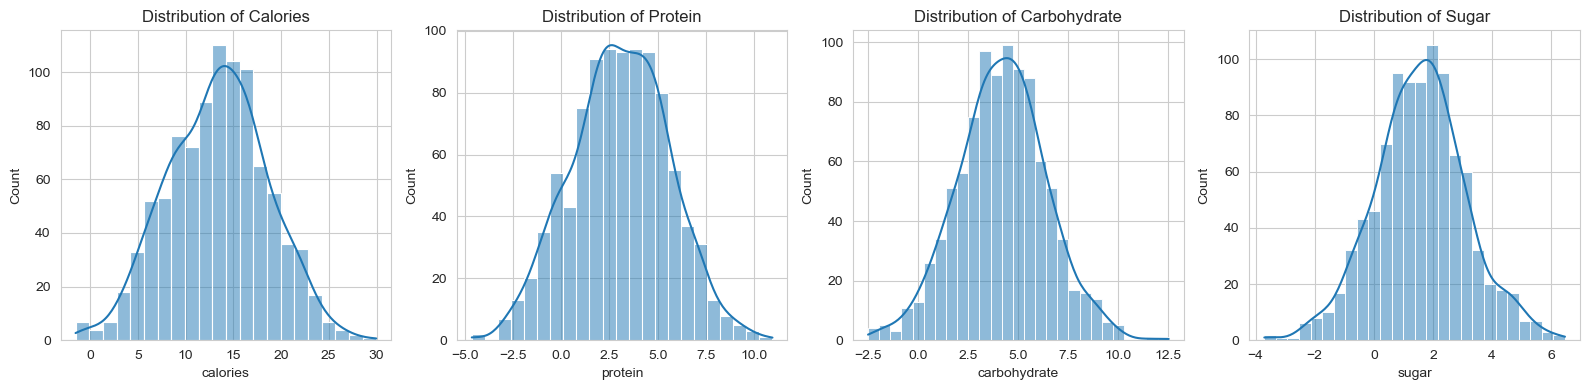

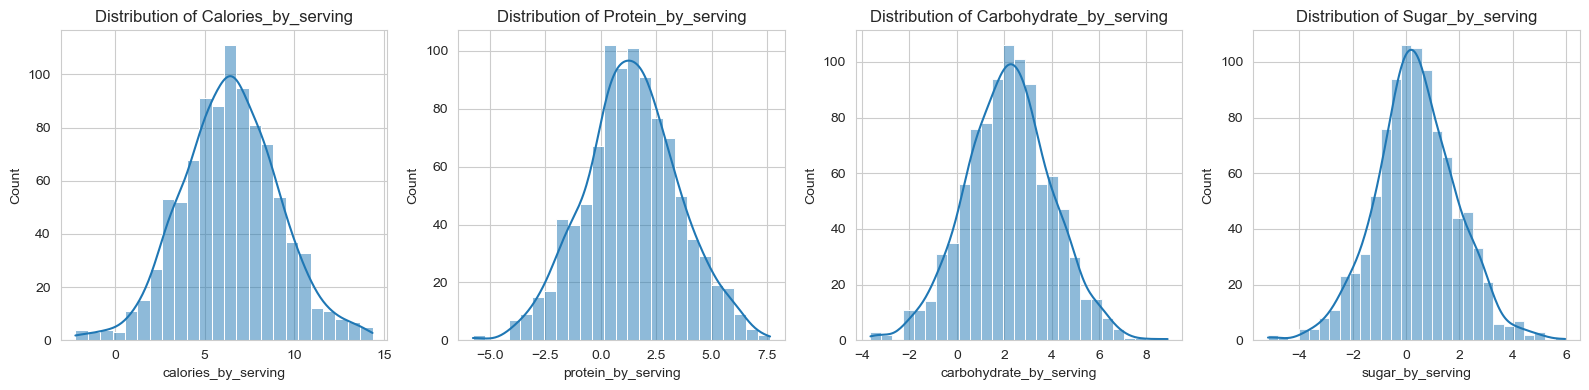

In [24]:
plt.figure(figsize=(16, 4))

for i, column in enumerate(nutrients_column):
    plt.subplot(1, len(nutrients_column), i+1)
    sns.histplot(data=data_transformed, x=column, kde=True)
    plt.title(f"Distribution of {column.capitalize()}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))

for i, column in enumerate(nutrients_by_serving):
    plt.subplot(1, len(nutrients_by_serving), i+1)
    sns.histplot(data=data_by_servings_transformed, x=column, kde=True)
    plt.title(f"Distribution of {column.capitalize()}")

plt.tight_layout()
plt.show()

1. **Nutrient Data**:
   - Initial Shapiro-Wilk tests revealed significant skewness in all nutrient columns, indicating non-normal distributions.

2. **Serving Sizes**:
   - Nutrient content per serving was calculated to derive additional insights:
     - Created columns `calories_by_serving`, `protein_by_serving`, `carbohydrate_by_serving`, and `sugar_by_serving`.
   - Serving size adjustments allowed for better comparison between recipes with varying serving sizes.

#### Transformation to Address Skewness
1. **Box-Cox Transformation**:
   - Applied Box-Cox transformation to both original nutrient columns and derived nutrient-per-serving columns to improve normality.
   - Post-transformation Shapiro-Wilk tests showed substantial improvements in normality for all columns:
     - Original nutrient columns (e.g., `calories`, `protein`, etc.) achieved near-normal distributions.
     - Derived `*_by_serving` columns also achieved improved normality, though `sugar_by_serving` retained some skewness.

#### Key Observations and Insights
1. **Normality Improvement**:
   - Non-normal distributions in the original dataset required transformation for use in statistical analyses and machine learning models.
   - The transformation successfully addressed skewness in most columns, as evidenced by Shapiro-Wilk statistics and visualization.


In [25]:
for col in nutrients_column:
    stat, p = ttest_ind(
        data_transformed[data_transformed['traffic'] == 1][col], 
        data_transformed[data_transformed['traffic'] == 0][col]
    )
    print(f"T-test for {col}: t-statistic = {stat:.3f}, p-value = {p:.5f}")

for col in nutrients_by_serving:
    stat, p = ttest_ind(
        data_by_servings_transformed[data_by_servings_transformed['traffic'] == 1][col], 
        data_by_servings_transformed[data_by_servings_transformed['traffic'] == 0][col]
    )
    print(f"T-test for {col}: t-statistic = {stat:.3f}, p-value = {p:.5f}")

T-test for calories: t-statistic = 2.118, p-value = 0.03445
T-test for protein: t-statistic = 4.030, p-value = 0.00006
T-test for carbohydrate: t-statistic = 1.806, p-value = 0.07127
T-test for sugar: t-statistic = -1.995, p-value = 0.04631
T-test for calories_by_serving: t-statistic = 1.175, p-value = 0.24027
T-test for protein_by_serving: t-statistic = 3.580, p-value = 0.00036
T-test for carbohydrate_by_serving: t-statistic = 0.975, p-value = 0.32979
T-test for sugar_by_serving: t-statistic = -2.323, p-value = 0.02041


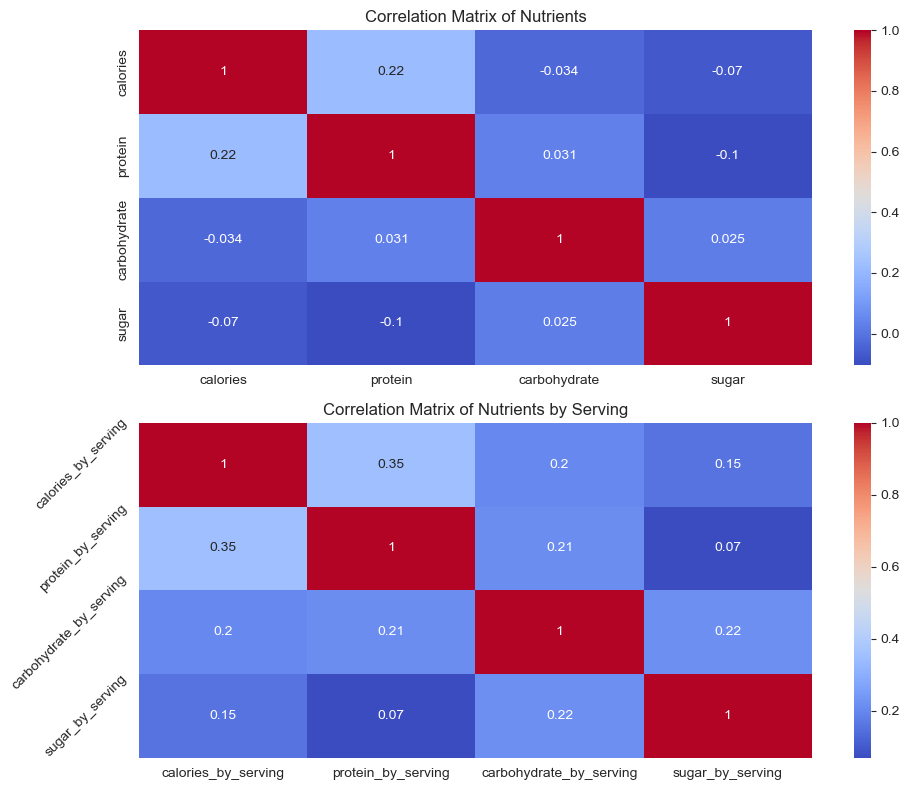

In [26]:
data_nutrients_corr = data_transformed[nutrients_column].corr()
data_nutrients_by_servings_corr = data_by_servings_transformed[nutrients_by_serving].corr()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

sns.heatmap(data_nutrients_corr, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation Matrix of Nutrients')

sns.heatmap(data_nutrients_by_servings_corr, annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Matrix of Nutrients by Serving')
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

In [27]:
for col in nutrients_column:
    stat, p = pointbiserialr(data['traffic'], data[col])
    print(f"Point Biserial Correlation for {col}: r = {stat:.3f}, p-value = {p:.5f}")

for col in nutrients_by_serving:
    stat, p = pointbiserialr(data['traffic'], data_by_servings[col])
    print(f"Point Biserial Correlation for {col}: r = {stat:.3f}, p-value = {p:.5f}")

Point Biserial Correlation for calories: r = 0.069, p-value = 0.03448
Point Biserial Correlation for protein: r = 0.038, p-value = 0.24699
Point Biserial Correlation for carbohydrate: r = 0.072, p-value = 0.02588
Point Biserial Correlation for sugar: r = -0.079, p-value = 0.01537
Point Biserial Correlation for calories_by_serving: r = 0.044, p-value = 0.17824
Point Biserial Correlation for protein_by_serving: r = 0.022, p-value = 0.49632
Point Biserial Correlation for carbohydrate_by_serving: r = 0.054, p-value = 0.09391
Point Biserial Correlation for sugar_by_serving: r = -0.065, p-value = 0.04401


In [28]:
data_transformed = pd.get_dummies(data_transformed, columns=['category'])
data_by_servings_transformed = pd.get_dummies(data_by_servings_transformed, columns=['category'])

for df in [data_transformed, data_by_servings_transformed]:
    df.replace({False: 0, True: 1}, inplace=True)

C:\Users\EK\AppData\Local\Temp\ipykernel_6852\3428882159.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({False: 0, True: 1}, inplace=True)


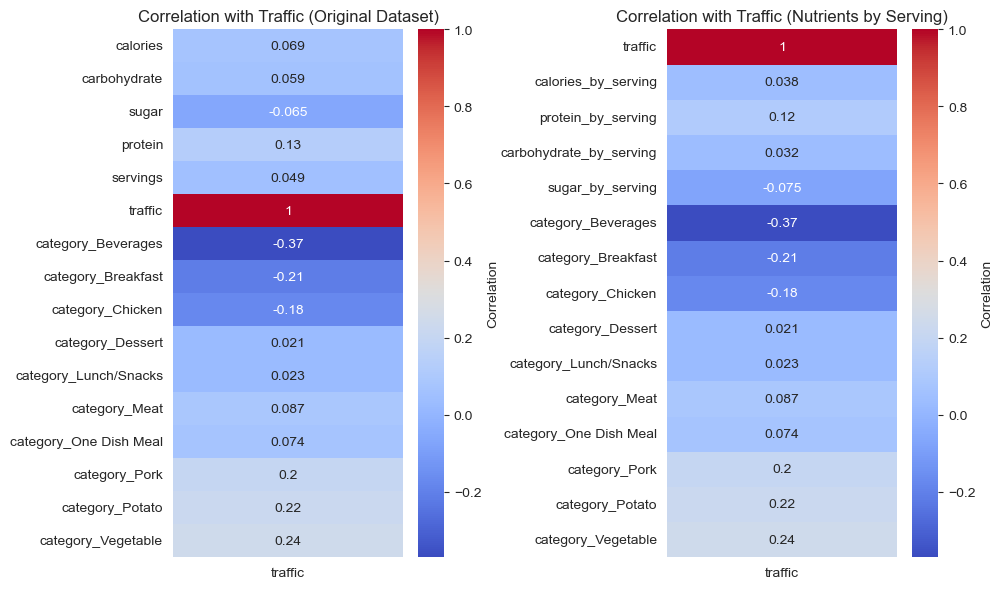

In [29]:
data_transformed['traffic'] = pd.to_numeric(data_transformed['traffic'], errors='coerce')
data_by_servings_transformed['traffic'] = pd.to_numeric(data_by_servings_transformed['traffic'], errors='coerce')

data_corr = data_transformed.corr()
data_by_servings_corr = data_by_servings_transformed.corr()

traffic_corr = data_transformed.corr()[['traffic']]
traffic_by_servings_corr = data_by_servings_transformed.corr()[['traffic']]

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sns.heatmap(traffic_corr, annot=True, cmap='coolwarm', ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation with Traffic (Original Dataset)')

sns.heatmap(traffic_by_servings_corr, annot=True, cmap='coolwarm', ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Correlation with Traffic (Nutrients by Serving)')

plt.tight_layout()
plt.show()

In [30]:
print(f"Correlation with Traffic (Original Dataset):")
for col in data_corr.columns:
    if col != 'traffic':
        stat, p = pointbiserialr(data_transformed['traffic'], data_transformed[col])
        print(f"Point Biserial Correlation for {col}: r = {stat:.3f}, p-value = {p:.5f}")

print(f"\nCorrelation with Traffic (Nutrients by Servings):")
for col in data_by_servings_corr.columns:
    if col != 'traffic':
        stat, p = pointbiserialr(data_by_servings_transformed['traffic'], data_by_servings_transformed[col])
        print(f"Point Biserial Correlation for {col}: r = {stat:.3f}, p-value = {p:.5f}")

Correlation with Traffic (Original Dataset):
Point Biserial Correlation for calories: r = 0.069, p-value = 0.03445
Point Biserial Correlation for carbohydrate: r = 0.059, p-value = 0.07127
Point Biserial Correlation for sugar: r = -0.065, p-value = 0.04631
Point Biserial Correlation for protein: r = 0.130, p-value = 0.00006
Point Biserial Correlation for servings: r = 0.049, p-value = 0.13418
Point Biserial Correlation for category_Beverages: r = -0.370, p-value = 0.00000
Point Biserial Correlation for category_Breakfast: r = -0.214, p-value = 0.00000
Point Biserial Correlation for category_Chicken: r = -0.175, p-value = 0.00000
Point Biserial Correlation for category_Dessert: r = 0.021, p-value = 0.52720
Point Biserial Correlation for category_Lunch/Snacks: r = 0.023, p-value = 0.48678
Point Biserial Correlation for category_Meat: r = 0.087, p-value = 0.00747
Point Biserial Correlation for category_One Dish Meal: r = 0.074, p-value = 0.02356
Point Biserial Correlation for category_Por

### Further Analysis of Nutrients and Nutrients by Serving

#### Insights from T-tests
1. **Significant Differences Across Traffic Groups**:
   - **Calories**: A statistically significant difference is observed between high and low traffic recipes with a p-value of 0.03445.
   - **Protein**: Strong evidence of a difference (p-value = 0.00006), indicating protein levels vary substantially between high and low traffic recipes.
   - **Sugar**: A significant difference is detected (p-value = 0.04631), suggesting sugar content may influence traffic.
   - **Carbohydrates**: Borderline significance (p-value = 0.07127), but not strongly conclusive.

2. **Nutrients by Serving**:
   - **Protein by Serving**: The only significant metric with a p-value of 0.00036, indicating it may be an important feature for distinguishing high traffic recipes.
   - **Sugar by Serving**: Significant difference (p-value = 0.02041), suggesting sugar per serving could have an impact.
   - **Calories and Carbohydrates by Serving**: No significant differences were observed, which aligns with the general trend seen in their raw counterparts.

#### Insights from Point Biserial Correlation
1. **Correlations with High Traffic**:
   - **Calories (r = 0.069)** and **Carbohydrates (r = 0.072)** show weak positive correlations with high traffic recipes but remain statistically significant.
   - **Sugar (r = -0.079)** exhibits a weak negative correlation with high traffic recipes and is significant.
   - **Protein** shows no significant correlation (p-value = 0.24699), despite its significant difference observed in the T-test.

2. **Nutrients by Serving**:
   - **Sugar by Serving (r = -0.065)** displays a weak negative correlation and is statistically significant.
   - Other features (e.g., calories, protein, carbohydrates by serving) show no significant correlation, which may limit their interpretability in modeling high traffic recipes.

#### Insights from Correlation Matrices
1. **Original Dataset**:
   - **Category Correlations**:
     - Strong negative correlations for `category_Beverages (-0.37)` and `category_Breakfast (-0.21)` with traffic indicate these categories are associated with lower traffic.
     - Positive correlations for `category_Pork (0.20)`, `category_Potato (0.22)`, and `category_Vegetable (0.24)` suggest these categories are likely linked to higher traffic.
   - **Nutrients**:
     - Weak positive correlations between traffic and `calories (0.069)` and `protein (0.13)`.
     - Weak negative correlation with `sugar (-0.065)`.

2. **Nutrients by Serving**:
   - The correlation matrix for nutrients normalized by servings highlights similar patterns:
     - **Sugar by Serving (-0.075)** retains its weak negative correlation with traffic.
     - Categories like `category_Beverages (-0.37)` and `category_Pork (0.20)` maintain their interpretability as significant predictors.

#### Recommendations for Features
1. **Include the following features for the logistic regression model**:
   - **Significant nutrients and nutrients by serving**:
     - `calories`, `protein`, and `sugar`.
     - `protein_by_serving` and `sugar_by_serving`.
   - **Significant categories**:
     - `category_Beverages`, `category_Breakfast`, `category_Pork`, `category_Potato`, and `category_Vegetable`.
     


In [31]:
traffic_proportions = data['traffic'].value_counts(normalize=True)
print(traffic_proportions)

traffic
1    0.606125
0    0.393875
Name: proportion, dtype: float64


In [32]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score

In [33]:
data_transformed_scaled = data_transformed.copy()
data_by_servings_transformed_scaled = data_by_servings_transformed.copy()

scaler = StandardScaler()

for col in nutrients_column:
    data_transformed_scaled[col] = scaler.fit_transform(data_transformed_scaled[[col]])

for col in nutrients_by_serving:
    data_by_servings_transformed_scaled[col] = scaler.fit_transform(data_by_servings_transformed_scaled[[col]])


In [34]:
X = data_transformed_scaled.drop(columns='traffic')
y = data_transformed_scaled['traffic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred_base = model.predict(X_test)
y_pred_proba_base = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba_base))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_base))
print("\nClassification Report:\n", classification_report(y_test, y_pred_base))

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:\n", coefficients)

Accuracy: 0.7842105263157895
AUC-ROC: 0.8700289855072465

Confusion Matrix:
 [[62 13]
 [28 87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.83      0.75        75
           1       0.87      0.76      0.81       115

    accuracy                           0.78       190
   macro avg       0.78      0.79      0.78       190
weighted avg       0.80      0.78      0.79       190


Feature Importance:
                    Feature  Coefficient
14      category_Vegetable     2.320133
13         category_Potato     1.721861
12           category_Pork     1.306639
11  category_One Dish Meal     0.282259
10           category_Meat     0.221615
3                  protein     0.048381
4                 servings     0.015721
1             carbohydrate    -0.003377
0                 calories    -0.010158
2                    sugar    -0.038445
8         category_Dessert    -0.154729
9    category_Lunch/Snacks    -0.204261
7         

In [35]:
X = data_transformed.drop(columns='traffic')
y = data_transformed['traffic']

X_by_servings = data_by_servings_transformed.drop(columns='traffic')
y_by_servings = data_by_servings_transformed['traffic']

X_scaled = data_transformed_scaled.drop(columns='traffic')
X_by_servings_scaled = data_by_servings_transformed_scaled.drop(columns='traffic')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_by_servings, X_test_by_servings, y_train_by_servings, y_test_by_servings = train_test_split(X_by_servings, y_by_servings, test_size=0.2, random_state=42, stratify=y_by_servings)

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train_by_servings_scaled, X_test_by_servings_scaled, y_train_by_servings_scaled, y_test_by_servings_scaled = train_test_split(X_by_servings_scaled, y_by_servings, test_size=0.2, random_state=42, stratify=y_by_servings)

In [36]:
def build_model(model, X_train, y_train, X_test, y_test, param_grid=None, cv=5):
    """
    Build and evaluate a model, optionally performing hyperparameter tuning.

    Parameters:
    - model: The machine learning model (e.g., RandomForestClassifier).
    - X_train, y_train: Training data and labels.
    - X_test, y_test: Testing data and labels.
    - param_grid: Hyperparameter grid for tuning (default: None).
    - cv: Number of cross-validation folds (default: 5).

    Returns:
    - evaluation: A dictionary with train and test metrics.
    - best_params: Best parameters if tuning is performed, otherwise None.
    - best_model: The trained model (either tuned or original).
    """
    if param_grid:
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=cv,
            n_jobs=-1,
            verbose=2,
            scoring='f1'
        )
        grid_search.fit(X_train, y_train)
        
        best_params = grid_search.best_params_
        best_model = grid_search.best_estimator_
        print("Tuning Completed.")
        print("Best Parameters:", best_params)
    else:
        best_model = model
        best_model.fit(X_train, y_train)
        best_params = None
        print("No Tuning Performed.")

    evaluation = {}
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)

    y_pred_test_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred_train_proba = best_model.predict_proba(X_train)[:, 1]

    model_train_f1 = f1_score(y_train, y_pred_train)
    model_train_auc = roc_auc_score(y_train, y_pred_train_proba)
    model_train_cr = classification_report(y_train, y_pred_train)
    model_train_cm = confusion_matrix(y_train, y_pred_train)

    evaluation['train'] = [model_train_auc, model_train_cr, model_train_cm, model_train_f1]

    model_test_f1 = f1_score(y_test, y_pred_test)
    model_test_auc = roc_auc_score(y_test, y_pred_test_proba)
    model_test_cr = classification_report(y_test, y_pred_test)
    model_test_cm = confusion_matrix(y_test, y_pred_test)

    evaluation['test'] = [model_test_auc, model_test_cr, model_test_cm, model_test_f1]

    return evaluation, best_params, best_model


In [37]:
def print_evaluation(evaluation):
        print(f"F1: {evaluation[3]:.3f}")
        print(f"AUC: {evaluation[0]:.3f}")
        print("Classification Report:")
        print(evaluation[1])
        print("Confusion Matrix:")
        print(evaluation[2])
        print("-" * 40)

In [38]:
lr = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, random_state=42, class_weight='balanced')
lr_by_servings = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, random_state=42, class_weight='balanced')

lr_evaluation, bp_lr, lr_model  = build_model(lr, X_train, y_train, X_test, y_test)
lr_by_servings_evaluation, bp_lr_by_servings, lr_by_servings_model = build_model(lr_by_servings, X_train_by_servings, y_train_by_servings, X_test_by_servings, y_test_by_servings)

No Tuning Performed.
No Tuning Performed.


In [39]:
print("Logistic Regression Train (Original Dataset):")
print_evaluation(lr_evaluation['train'])

print("Logistic Regression Test (Original Dataset):")
print_evaluation(lr_evaluation['test'])

print("Logistic Regression Train (Nutrients by Serving):")
print_evaluation(lr_by_servings_evaluation['train'])

print("Logistic Regression Test (Nutrients by Serving):")
print_evaluation(lr_by_servings_evaluation['test'])

Logistic Regression Train (Original Dataset):
F1: 0.793
AUC: 0.827
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.69      0.68       298
           1       0.80      0.79      0.79       459

    accuracy                           0.75       757
   macro avg       0.74      0.74      0.74       757
weighted avg       0.75      0.75      0.75       757

Confusion Matrix:
[[205  93]
 [ 96 363]]
----------------------------------------
Logistic Regression Test (Original Dataset):
F1: 0.809
AUC: 0.870
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.83      0.75        75
           1       0.87      0.76      0.81       115

    accuracy                           0.78       190
   macro avg       0.78      0.79      0.78       190
weighted avg       0.80      0.78      0.79       190

Confusion Matrix:
[[62 13]
 [28 87]]
----------------------------------------
Logisti

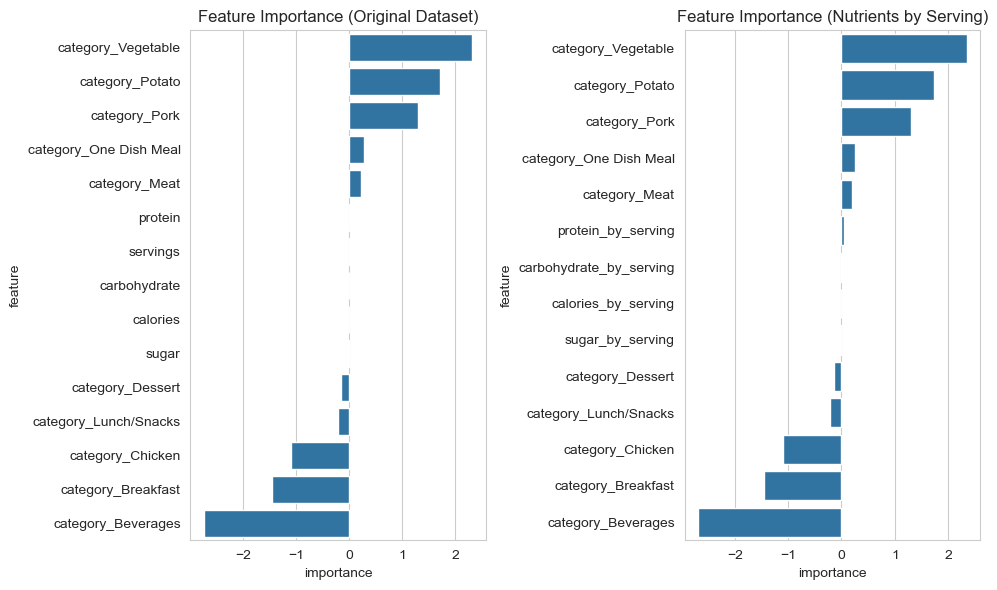

In [40]:
feature_importance_lr = pd.DataFrame({
    'feature': X.columns,
    'importance': lr_model.coef_[0]
}).sort_values(by='importance', ascending=False)

feature_importance_lr_by_servings = pd.DataFrame({
    'feature': X_by_servings.columns,
    'importance': lr_by_servings_model.coef_[0]
}).sort_values(by='importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sns.barplot(data=feature_importance_lr, x='importance', y='feature', ax=axes[0])
axes[0].set_title('Feature Importance (Original Dataset)')

sns.barplot(data=feature_importance_lr_by_servings, x='importance', y='feature', ax=axes[1])
axes[1].set_title('Feature Importance (Nutrients by Serving)')

plt.tight_layout()
plt.show()

In [41]:
print(feature_importance_lr)

                   feature  importance
14      category_Vegetable    2.323627
13         category_Potato    1.721384
12           category_Pork    1.302554
11  category_One Dish Meal    0.277506
10           category_Meat    0.218330
3                  protein    0.020689
4                 servings    0.015816
1             carbohydrate    0.000099
0                 calories   -0.001100
2                    sugar   -0.023845
8         category_Dessert   -0.156737
9    category_Lunch/Snacks   -0.206559
7         category_Chicken   -1.085442
6       category_Breakfast   -1.444724
5       category_Beverages   -2.736847


In [42]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_by_serving = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_evaluation, bp_rf, rf_model = build_model(rf, X_train, y_train, X_test, y_test)
rf_by_servings_evaluation, bp_rf_by_serv, rf_by_serv_model = build_model(rf_by_serving, X_train_by_servings, y_train_by_servings, X_test_by_servings, y_test_by_servings)

print("Random Forest Train (Original Dataset)")
print_evaluation(rf_evaluation['train'])

print("Random Forest Test (Original Dataset)")
print_evaluation(rf_evaluation['test'])

print("Random Forest Train (Nutrients by Serving)")
print_evaluation(rf_by_servings_evaluation['train'])

print("Random Forest Test (Nutrients by Serving)")
print_evaluation(rf_by_servings_evaluation['test'])

No Tuning Performed.
No Tuning Performed.
Random Forest Train (Original Dataset)
F1: 0.998
AUC: 1.000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       298
           1       1.00      1.00      1.00       459

    accuracy                           1.00       757
   macro avg       1.00      1.00      1.00       757
weighted avg       1.00      1.00      1.00       757

Confusion Matrix:
[[296   2]
 [  0 459]]
----------------------------------------
Random Forest Test (Original Dataset)
F1: 0.761
AUC: 0.833
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.68        75
           1       0.81      0.72      0.76       115

    accuracy                           0.73       190
   macro avg       0.72      0.73      0.72       190
weighted avg       0.74      0.73      0.73       190

Confusion Matrix:
[[55 20]
 [32 83]]
--------------------

In [43]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_tuned_evaluation, bp_rf_tuned, rf_tuned_model = build_model(rf, X_train, y_train, X_test, y_test, param_grid=param_grid)
rf_by_servings_tuned_evaluation, bp_rf_by_servings_tuned, rf_by_servings_tuned_model = build_model(rf_by_serving, X_train_by_servings, y_train_by_servings, X_test_by_servings, y_test_by_servings, param_grid=param_grid)

print("Random Forest Tuned Train (Original Dataset)")
print_evaluation(rf_tuned_evaluation['train'])

print("Random Forest Tuned Test (Original Dataset)")
print_evaluation(rf_tuned_evaluation['test'])

print("Random Forest Tuned Train (Nutrients by Serving)")
print_evaluation(rf_by_servings_tuned_evaluation['train'])

print("Random Forest Tuned Test (Nutrients by Serving)")
print_evaluation(rf_by_servings_tuned_evaluation['test'])

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Tuning Completed.
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Tuning Completed.
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Tuned Train (Original Dataset)
F1: 0.998
AUC: 1.000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       298
           1       1.00      1.00      1.00       459

    accuracy                           1.00       757
   macro avg       1.00      1.00      1.00       757
weighted avg       1.00      1.00      1.00       757

Confusion Matrix:
[[296   2]
 [  0 459]]
----------------------------------------
Random Forest Tuned Test (Original Dataset)
F1: 0.784
AUC: 0.835
Classification Report:
              precision    recall  f1-score   sup

In [44]:
svm = SVC(probability=True, random_state=42, class_weight='balanced')
svm_by_serving = SVC(probability=True, random_state=42, class_weight='balanced')

svm_evaluation, bp_svm, svm_model = build_model(svm, X_train_scaled, y_train, X_test_scaled, y_test)
svm_by_servings_evaluation, bp_svm_by_serv, svm_by_serv_model = build_model(svm_by_serving, X_train_by_servings_scaled, y_train_by_servings, X_test_by_servings_scaled, y_test_by_servings)

print("SVM Train (Original Dataset)")
print_evaluation(svm_evaluation['train'])

print("SVM Test (Original Dataset)")
print_evaluation(svm_evaluation['test'])

print("SVM Train (Nutrients by Serving)")
print_evaluation(svm_by_servings_evaluation['train'])

print("SVM Test (Nutrients by Serving)")
print_evaluation(svm_by_servings_evaluation['test'])

No Tuning Performed.
No Tuning Performed.
SVM Train (Original Dataset)
F1: 0.808
AUC: 0.841
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.68      0.70       298
           1       0.80      0.82      0.81       459

    accuracy                           0.76       757
   macro avg       0.75      0.75      0.75       757
weighted avg       0.76      0.76      0.76       757

Confusion Matrix:
[[204  94]
 [ 84 375]]
----------------------------------------
SVM Test (Original Dataset)
F1: 0.804
AUC: 0.831
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.79      0.73        75
           1       0.85      0.77      0.80       115

    accuracy                           0.77       190
   macro avg       0.77      0.78      0.77       190
weighted avg       0.78      0.77      0.78       190

Confusion Matrix:
[[59 16]
 [27 88]]
----------------------------------------

In [45]:
svm_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']
}

svm_tuned_evaluation, bp_svm_tuned, svm_tuned_model = build_model(svm, X_train_scaled, y_train, X_test_scaled, y_test, param_grid=svm_param_grid)
svm_by_servings_tuned_evaluation, bp_svm_by_servings_tuned, svm_by_servings_tuned_model = build_model(svm_by_serving, X_train_by_servings_scaled, y_train_by_servings, X_test_by_servings_scaled, y_test_by_servings, param_grid=svm_param_grid)

print("SVM Tuned Train (Original Dataset)")
print_evaluation(svm_tuned_evaluation['train'])

print("SVM Tuned Test (Original Dataset)")
print_evaluation(svm_tuned_evaluation['test'])

print("SVM Tuned Train (Nutrients by Serving)")
print_evaluation(svm_by_servings_tuned_evaluation['train'])

print("SVM Tuned Test (Nutrients by Serving)")
print_evaluation(svm_by_servings_tuned_evaluation['test'])

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Tuning Completed.
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Tuning Completed.
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
SVM Tuned Train (Original Dataset)
F1: 0.803
AUC: 0.786
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.67      0.69       298
           1       0.79      0.81      0.80       459

    accuracy                           0.76       757
   macro avg       0.75      0.74      0.74       757
weighted avg       0.76      0.76      0.76       757

Confusion Matrix:
[[200  98]
 [ 85 374]]
----------------------------------------
SVM Tuned Test (Original Dataset)
F1: 0.809
AUC: 0.815
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.79      0.74        75
           1       0.85      0.77      0.81  

In [46]:
gb = GradientBoostingClassifier(random_state=42)
gb_by_serving = GradientBoostingClassifier(random_state=42)

gb_evaluation, bp_gb, gb_model = build_model(gb, X_train, y_train, X_test, y_test)
gb_by_servings_evaluation, bp_gb_by_serv, gb_by_serv_model = build_model(gb_by_serving, X_train_by_servings, y_train_by_servings, X_test_by_servings, y_test_by_servings)

print("Gradient Boosting Train (Original Dataset)")
print_evaluation(gb_evaluation['train'])

print("Gradient Boosting Test (Original Dataset)")
print_evaluation(gb_evaluation['test'])

print("Gradient Boosting Train (Nutrients by Serving)")
print_evaluation(gb_by_servings_evaluation['train'])

print("Gradient Boosting Test (Nutrients by Serving)")
print_evaluation(gb_by_servings_evaluation['test'])

No Tuning Performed.
No Tuning Performed.
Gradient Boosting Train (Original Dataset)
F1: 0.888
AUC: 0.948
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       298
           1       0.87      0.91      0.89       459

    accuracy                           0.86       757
   macro avg       0.86      0.85      0.85       757
weighted avg       0.86      0.86      0.86       757

Confusion Matrix:
[[236  62]
 [ 43 416]]
----------------------------------------
Gradient Boosting Test (Original Dataset)
F1: 0.788
AUC: 0.851
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        75
           1       0.80      0.77      0.79       115

    accuracy                           0.75       190
   macro avg       0.74      0.74      0.74       190
weighted avg       0.75      0.75      0.75       190

Confusion Matrix:
[[53 22]
 [26 89]]
------------

In [47]:
gb_param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'learning_rate': [0.01, 0.1, 1]
}

gb_tuned_evaluation, bp_gb_tuned, gb_tuned_model = build_model(gb, X_train, y_train, X_test, y_test, param_grid=gb_param_grid)
gb_by_servings_tuned_evaluation, bp_gb_by_servings_tuned, gb_by_servings_tuned_model = build_model(gb_by_serving, X_train_by_servings, y_train_by_servings, X_test_by_servings, y_test_by_servings, param_grid=gb_param_grid)

print("Gradient Boosting Tuned Train (Original Dataset)")
print_evaluation(gb_tuned_evaluation['train'])

print("Gradient Boosting Tuned Test (Original Dataset)")
print_evaluation(gb_tuned_evaluation['test'])

print("Gradient Boosting Tuned Train (Nutrients by Serving)")
print_evaluation(gb_by_servings_tuned_evaluation['train'])

print("Gradient Boosting Tuned Test (Nutrients by Serving)")
print_evaluation(gb_by_servings_tuned_evaluation['test'])

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Tuning Completed.
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Tuning Completed.
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Gradient Boosting Tuned Train (Original Dataset)
F1: 0.837
AUC: 0.899
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       298
           1       0.83      0.85      0.84       459

    accuracy                           0.80       757
   macro avg       0.79      0.79      0.79       757
weighted avg       0.80      0.80      0.80       757

Confusion Matrix:
[[216  82]
 [ 70 389]]
----------------------------------------
Gradient Boosting Tuned Test (Original Dataset)
F1: 0.787
AUC: 0.852
Classification Rep

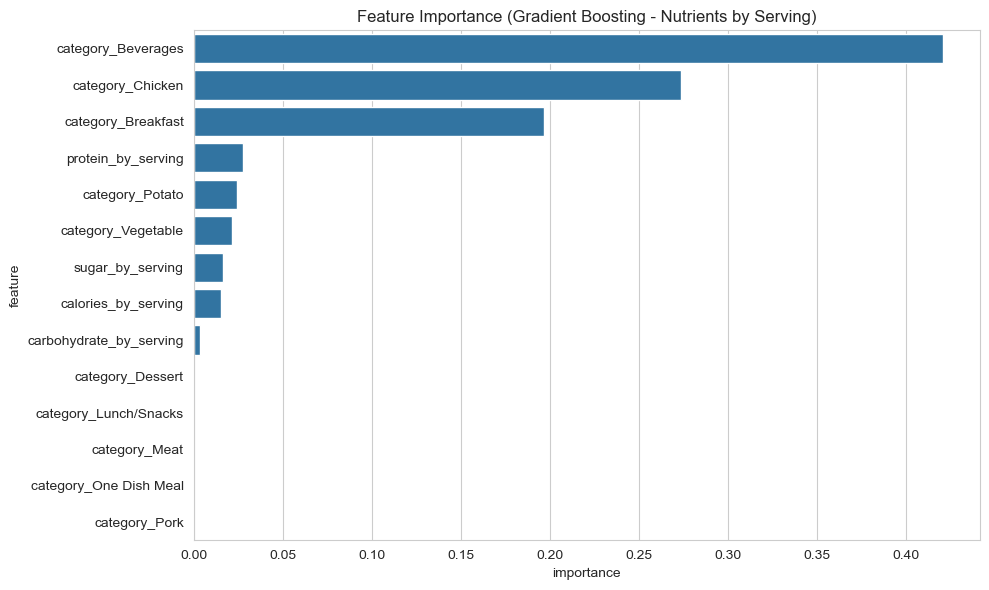

In [48]:
feature_importance_gb_by_servings = pd.DataFrame({
    'feature': X_by_servings.columns,
    'importance': gb_by_servings_tuned_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_gb_by_servings, x='importance', y='feature')
plt.title('Feature Importance (Gradient Boosting - Nutrients by Serving)')

plt.tight_layout()
plt.show()

In [49]:
print(feature_importance_gb_by_servings)

                    feature  importance
4        category_Beverages    0.420525
6          category_Chicken    0.273472
5        category_Breakfast    0.196733
1        protein_by_serving    0.027589
12          category_Potato    0.024579
13       category_Vegetable    0.021375
3          sugar_by_serving    0.016736
0       calories_by_serving    0.015449
2   carbohydrate_by_serving    0.003543
7          category_Dessert    0.000000
8     category_Lunch/Snacks    0.000000
9             category_Meat    0.000000
10   category_One Dish Meal    0.000000
11            category_Pork    0.000000


In [50]:
#Comparison of all test results

models = ['Logistic Regression', 'Random Forest', 'Random Forest Tuned', 'SVM', 'SVM Tuned', 'Gradient Boosting', 'Gradient Boosting Tuned']
original_dataset = [lr_evaluation['test'][0], rf_evaluation['test'][0], rf_tuned_evaluation['test'][0], svm_evaluation['test'][0], svm_tuned_evaluation['test'][0], gb_evaluation['test'][0], gb_tuned_evaluation['test'][0]]
nutrients_by_serving = [lr_by_servings_evaluation['test'][0], rf_by_servings_evaluation['test'][0], rf_by_servings_tuned_evaluation['test'][0], svm_by_servings_evaluation['test'][0], svm_by_servings_tuned_evaluation['test'][0], gb_by_servings_evaluation['test'][0], gb_by_servings_tuned_evaluation['test'][0]]

comparison = pd.DataFrame({
    'Model': models,
    'Original Dataset': original_dataset,
    'Nutrients by Serving': nutrients_by_serving
})

comparison.set_index('Model', inplace=True)

print(f"AUC Comparison of Models:")
print(comparison)

original_f1 = [lr_evaluation['test'][3], rf_evaluation['test'][3], rf_tuned_evaluation['test'][3], svm_evaluation['test'][3], svm_tuned_evaluation['test'][3], gb_evaluation['test'][3], gb_tuned_evaluation['test'][3]]
by_serving_f1 = [lr_by_servings_evaluation['test'][3], rf_by_servings_evaluation['test'][3], rf_by_servings_tuned_evaluation['test'][3], svm_by_servings_evaluation['test'][3], svm_by_servings_tuned_evaluation['test'][3], gb_by_servings_evaluation['test'][3], gb_by_servings_tuned_evaluation['test'][3]]

comparison_f1 = pd.DataFrame({
    'Model': models,
    'Original Dataset': original_f1,
    'Nutrients by Serving': by_serving_f1
})

comparison_f1.set_index('Model', inplace=True)

print(f"F1 Comparison of Models:")
print(comparison_f1)


AUC Comparison of Models:
                         Original Dataset  Nutrients by Serving
Model                                                          
Logistic Regression              0.869797              0.866899
Random Forest                    0.832522              0.841449
Random Forest Tuned              0.835130              0.866783
SVM                              0.830609              0.816348
SVM Tuned                        0.815072              0.856232
Gradient Boosting                0.850609              0.852058
Gradient Boosting Tuned          0.851536              0.837855
F1 Comparison of Models:
                         Original Dataset  Nutrients by Serving
Model                                                          
Logistic Regression              0.809302              0.794393
Random Forest                    0.761468              0.774775
Random Forest Tuned              0.783784              0.792627
SVM                              0.803653            

In [51]:
#Classification report for all models

print("Classification Report for Logistic Regression (Original Dataset):")
print(lr_evaluation['test'][1])

print("Classification Report for Random Forest (Original Dataset):")
print(rf_evaluation['test'][1])

print("Classification Report for Random Forest Tuned (Original Dataset):")
print(rf_tuned_evaluation['test'][1])

print("Classification Report for SVM (Original Dataset):")
print(svm_evaluation['test'][1])

print("Classification Report for SVM Tuned (Original Dataset):")
print(svm_tuned_evaluation['test'][1])

print("Classification Report for Gradient Boosting (Original Dataset):")
print(gb_evaluation['test'][1])

print("Classification Report for Gradient Boosting Tuned (Original Dataset):")
print(gb_tuned_evaluation['test'][1])

Classification Report for Logistic Regression (Original Dataset):
              precision    recall  f1-score   support

           0       0.69      0.83      0.75        75
           1       0.87      0.76      0.81       115

    accuracy                           0.78       190
   macro avg       0.78      0.79      0.78       190
weighted avg       0.80      0.78      0.79       190

Classification Report for Random Forest (Original Dataset):
              precision    recall  f1-score   support

           0       0.63      0.73      0.68        75
           1       0.81      0.72      0.76       115

    accuracy                           0.73       190
   macro avg       0.72      0.73      0.72       190
weighted avg       0.74      0.73      0.73       190

Classification Report for Random Forest Tuned (Original Dataset):
              precision    recall  f1-score   support

           0       0.66      0.73      0.70        75
           1       0.81      0.76      0.78  

In [52]:
print("Classification Report for Logistic Regression (Nutrients by Serving):")
print(lr_by_servings_evaluation['test'][1])

print("Classification Report for Random Forest (Nutrients by Serving):")
print(rf_by_servings_evaluation['test'][1])

print("Classification Report for Random Forest Tuned (Nutrients by Serving):")
print(rf_by_servings_tuned_evaluation['test'][1])

print("Classification Report for SVM (Nutrients by Serving):")
print(svm_by_servings_evaluation['test'][1])

print("Classification Report for SVM Tuned (Nutrients by Serving):")
print(svm_by_servings_tuned_evaluation['test'][1])

print("Classification Report for Gradient Boosting (Nutrients by Serving):")
print(gb_by_servings_evaluation['test'][1])

print("Classification Report for Gradient Boosting Tuned (Nutrients by Serving):")
print(gb_by_servings_tuned_evaluation['test'][1])

Classification Report for Logistic Regression (Nutrients by Serving):
              precision    recall  f1-score   support

           0       0.67      0.81      0.73        75
           1       0.86      0.74      0.79       115

    accuracy                           0.77       190
   macro avg       0.76      0.78      0.76       190
weighted avg       0.78      0.77      0.77       190

Classification Report for Random Forest (Nutrients by Serving):
              precision    recall  f1-score   support

           0       0.65      0.72      0.68        75
           1       0.80      0.75      0.77       115

    accuracy                           0.74       190
   macro avg       0.73      0.73      0.73       190
weighted avg       0.74      0.74      0.74       190

Classification Report for Random Forest Tuned (Nutrients by Serving):
              precision    recall  f1-score   support

           0       0.67      0.79      0.72        75
           1       0.84      0.75